# What is Reaction Enumeration?
Reaction Enumeration is the process of automatically generating all possible product molecules by applying a reaction to multiple sets of reactants.
Instead of performing a reaction on one pair of reactants, Reaction Enumeration performs the same reaction on many combinations of reactants.

Simple Definition


Reaction SMARTS defines the reaction rule, while Reaction Enumeration applies that rule to many reactants to create a virtual library of products.

# why do we need reaction enumeration ?

Reaction Enumeration is one of the most important techniques in modern drug discovery because pharmaceutical companies rarely synthesize molecules one by one.
Instead,
they generate virtual libraries first.

# Example

We'll perform amide formation, one of the most common reactions in drug discovery.
We'll use:
2 carboxylic acids
2 amines
This will generate 4 possible amide products.

In [2]:
# Import Libraries

from rdkit import Chem
from rdkit.Chem import AllChem, Draw

In [3]:
# Define the reaction
# This Reaction SMARTS represents a simple amide formation.

reaction = AllChem.ReactionFromSmarts(
    "[C:1](=[O:2])[OH:3].[N:4]>>[C:1](=[O:2])[N:4]"
)

In [4]:
# Create reactants
# Carboxylic Acids

acids = [
    Chem.MolFromSmiles("CC(=O)O"),        # Acetic acid
    Chem.MolFromSmiles("c1ccccc1C(=O)O")  # Benzoic acid
]

# Amines 

amines = [
    Chem.MolFromSmiles("CN"),   # Methylamine
    Chem.MolFromSmiles("CCN")   # Ethylamine
]

In [5]:
# Enumerate the products

products = []

for acid in acids:
    for amine in amines:

        product = reaction.RunReactants((acid, amine))

        if product:
            products.append(product[0][0])

[12:02:07] mapped atoms in the reactants were not mapped in the products.
  unmapped numbers are: 3 


In [6]:
# Remove Duplicates ( optional but good practice )

unique_products = []

smiles_seen = set()

for mol in products:

    smiles = Chem.MolToSmiles(mol)

    if smiles not in smiles_seen:

        smiles_seen.add(smiles)

        unique_products.append(mol)

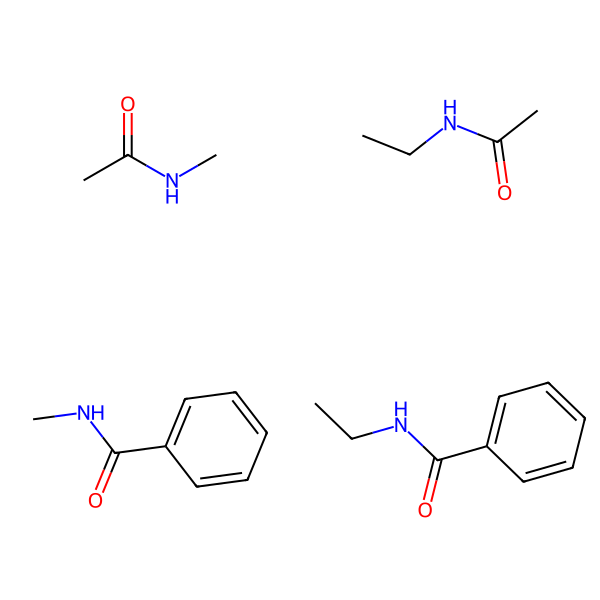

In [7]:
# Display the products

Draw.MolsToGridImage(
    unique_products,
    molsPerRow=2,
    subImgSize=(300,300)
)

## Interpretation

A reaction enumeration workflow was performed using a simple amide formation reaction.

Two carboxylic acids and two amines were combined using a Reaction SMARTS rule. RDKit automatically generated all possible combinations, resulting in four unique amide products.

This demonstrates how reaction enumeration enables rapid creation of virtual compound libraries, which are commonly used in medicinal chemistry for lead optimization, combinatorial chemistry, and virtual screening.